# Market weather: forecasting the volatility regime, and the traps that inflate it

*A self-contained walk-through for section 4 of the dissertation. We take a 17-symbol market panel and try to forecast next month's **volatility weather** - calm, normal, or stormy. Every number and figure below is produced by the code in this notebook. The point of the notebook is not the forecast itself but the **cleaning of the problem**: each design choice is made by a guess -> test -> fail -> fix loop that hunts down a hidden assumption before it can flatter us.*

**The story in one line:** most of the "forecastability" you can find in a market series is an artefact - of a single crisis day, of overlapping windows, of the wrong null hypothesis - and the honest signal that survives all of those audits is small (about +14%), which is exactly what we want to know before letting a deep network loose on it.

**Aims of this notebook**

- Clean a raw multi-market panel into comparable returns (crypto onto business days, winsorized tails).
- Decide **what** is forecastable: separate genuine volatility clustering from apparent direction signal, using the correct sign-shuffle null.
- Turn volatility into a **label** (calm / normal / stormy) on non-overlapping monthly blocks, and show why overlapping windows inflate persistence.
- Justify every labelling knob - baseline window, normalization method, number of levels, block size - by a small experiment rather than taste.
- Audit the whole pipeline for leaks before any deep learning, and fix an honest ceiling the network must not exceed.

*Reproducibility: every experiment that uses randomness seeds its own generator with `np.random.default_rng(...)`. Run from the repository root; the data path also resolves from `notebooks/`. Source of truth = `Docs/S4_WEATHER_REGIME.md`.*

## Step 0 - Data & clean

We are handed one CSV per market: a date and a daily close. Two things must happen before anything is comparable across 17 markets. First, crypto trades weekends while everything else does not, so we drop crypto weekends to put every series on the same business-day calendar. Second, raw daily returns carry the occasional absurd spike (a bad print, a thin-liquidity gap) that a single value can use to fake a pattern later, so we **winsorize** each symbol's returns to its 0.5% / 99.5% quantiles.

First the imports, the small colour palette used by every chart, and the two cleaning constants. `ROOT` is anchored so the data path resolves whether the kernel runs from the repo root or from `notebooks/`.

In [1]:
import csv, glob, os, datetime as dt
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

AC = "#3a6ea5"; MU = "#b8c0cc"; RD = "#c85a52"; GR = "#eef1f4"; GRN = "#2e7d32"; PUR = "#8e6fb0"
CRYPTO = {"BTCUSD", "ETHUSD"}
WINSOR = (0.5, 99.5)
ROOT = "." if os.path.isdir("data/panel") else ".."   # run from repo root or from notebooks/

The two building blocks. `load_raw` reads (date, close) pairs, skipping non-positive prices. `clean_symbol` puts crypto on business days, takes log-returns, and **winsorizes** them. Winsorizing clips each return $r_t$ to the empirical $0.5\%$ and $99.5\%$ quantiles of that symbol's own returns:

$$r_t^{\text{clean}} \;=\; \min\!\big(\max(r_t,\; q_{0.5}),\; q_{99.5}\big), \qquad q_p = \text{percentile}(r,\, p).$$

The code uses the same names: `lo`, `hi` are $q_{0.5}, q_{99.5}$ and `np.clip` is the $\min/\max$ pair.

In [2]:
def load_raw(path):
    dates = []; close = []
    for row in csv.DictReader(open(path)):
        try:
            close_val = float(row["Close"])
        except:
            continue
        if close_val <= 0:
            continue
        dates.append(dt.date.fromisoformat(row["Date"])); close.append(close_val)
    return dates, np.array(close)

def clean_symbol(name, dates, close):
    if name in CRYPTO:                                   # crypto -> business days only
        keep = [i for i, day in enumerate(dates) if day.weekday() < 5]
        dates = [dates[i] for i in keep]; close = close[keep]
    dates = dates[1:]
    returns = np.diff(np.log(close))                     # daily log-returns
    lo, hi = np.percentile(returns, WINSOR)              # 0.5 / 99.5 quantiles
    return dates, returns, np.clip(returns, lo, hi)      # winsorized (clean) returns

Now walk every panel CSV and build three parallel dictionaries: `raw_returns` (pre-winsor, kept only to prove the cleaning did something), `symbol_series` (dates + clean returns), and `clean_returns` (clean returns alone, our working object).

In [3]:
raw_returns = {}; symbol_series = {}
for path in sorted(glob.glob(f"{ROOT}/data/panel/*.csv")):
    name = os.path.basename(path)[:-4]
    if name.startswith("_"):
        continue
    raw_dates, raw_close = load_raw(path)
    dates, returns, clean = clean_symbol(name, raw_dates, raw_close)
    raw_returns[name] = returns
    symbol_series[name] = (dates, clean)
clean_returns = {symbol: symbol_series[symbol][1] for symbol in symbol_series}
print("STEP 0:", len(symbol_series), "symbols cleaned (crypto->business-days, winsor 0.5/99.5).")

STEP 0: 17 symbols cleaned (crypto->business-days, winsor 0.5/99.5).


A habit before modelling anything: check the shapes line up. Every symbol's clean-return series must match its date series length and its own raw series length (winsorizing clips values, never drops rows).

In [4]:
assert len(symbol_series) == 17
for symbol in symbol_series:
    dates, clean = symbol_series[symbol]
    assert len(dates) == len(clean) == len(raw_returns[symbol])
clean_returns["EURUSD"].shape

(5876,)

Does the winsorizing actually change anything, and does it throw the babies out with the bathwater? Three panels on EURUSD and US500: the glitch tamed, the outlier tail pulled in, and - crucially - the real crises (1987, 2008, 2020) still standing in the rolling volatility.

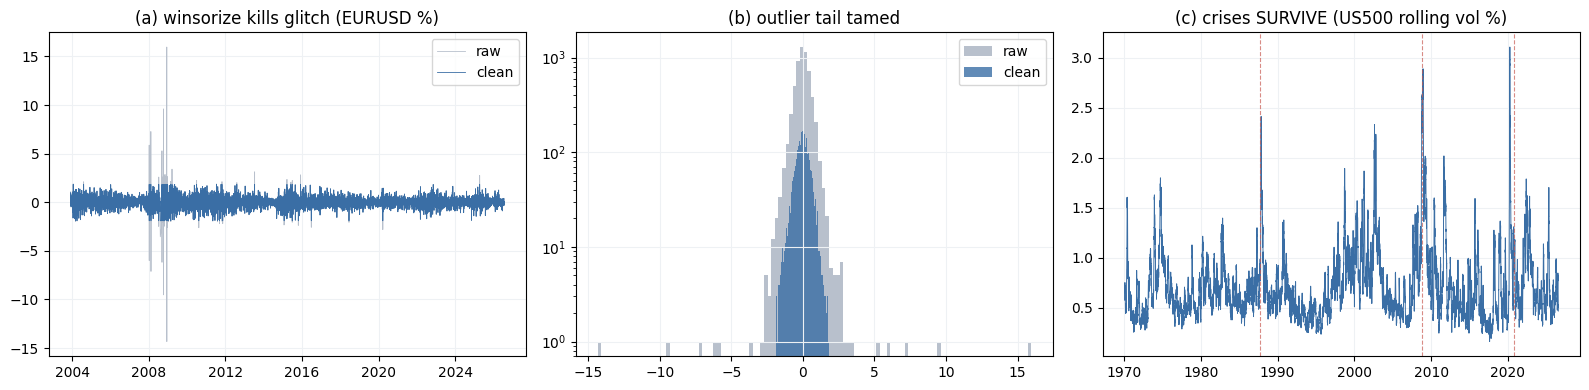

In [5]:
fig,ax=plt.subplots(1,3,figsize=(16,4.0))
dates_eur=symbol_series["EURUSD"][0]
ax[0].plot(dates_eur,raw_returns["EURUSD"]*100,color=MU,lw=.6,label="raw"); ax[0].plot(dates_eur,clean_returns["EURUSD"]*100,color=AC,lw=.6,label="clean")
ax[0].set_title("(a) winsorize kills glitch (EURUSD %)"); ax[0].legend(); ax[0].grid(True,color=GR)
ax[1].hist(raw_returns["EURUSD"]*100,bins=120,color=MU,log=True,label="raw"); ax[1].hist(clean_returns["EURUSD"]*100,bins=120,color=AC,alpha=.8,log=True,label="clean")
ax[1].set_title("(b) outlier tail tamed"); ax[1].legend(); ax[1].grid(True,color=GR)
returns_us=clean_returns["US500"]; dates_us=symbol_series["US500"][0]; rolling_vol=np.array([np.mean(np.abs(returns_us[i-20:i])) for i in range(20,len(returns_us))])*100
ax[2].plot(dates_us[20:],rolling_vol,color=AC,lw=.7)
for yr in (1987,2008,2020): ax[2].axvline(dt.date(yr,10,1),color=RD,ls="--",lw=.8,alpha=.7)
ax[2].set_title("(c) crises SURVIVE (US500 rolling vol %)"); ax[2].grid(True,color=GR)
plt.tight_layout(); plt.show()

Panels (a) and (b) show the winsorizing biting only the extreme tail; panel (c) is the reassurance that matters most - the October spikes of 1987, 2008 and 2020 survive intact, so we clipped noise, not signal.

The test that the winsorising is safe, in numbers: the crises must survive it. Take US500's mean daily roughness ($\text{mean}|r|$, in %) for the crisis years 2008 and 2020, raw versus winsorised, and compare both against a calm year. The clip pulls the wild days back a little, but the storms still tower several times over an ordinary year.

In [6]:
# US500 roughness = mean|ret| in %, per calendar year, raw vs winsorised (clean).
us_dates = symbol_series["US500"][0]
us_years = np.array([d.year for d in us_dates])
us_raw = raw_returns["US500"]; us_clean = clean_returns["US500"]

def year_roughness(year, series):
    mask = us_years == year
    return np.mean(np.abs(series[mask])) * 100

calm_year = min(set(us_years), key=lambda y: year_roughness(y, us_clean))
calm = year_roughness(calm_year, us_clean)
for year in (2008, 2020):
    raw_r = year_roughness(year, us_raw); clean_r = year_roughness(year, us_clean)
    print(f"US500 {year}: roughness raw {raw_r:.2f}% -> clean {clean_r:.2f}% a day "
          f"({clean_r/calm:.1f}x the calm year {calm_year} at {calm:.2f}%)")

US500 2008: roughness raw 1.74% -> clean 1.45% a day (4.8x the calm year 2017 at 0.30%)
US500 2020: roughness raw 1.35% -> clean 1.16% a day (3.9x the calm year 2017 at 0.30%)


## Step 1 - Two axes: keep volatility, drop direction

A market series offers two things one might try to forecast: **direction** (will tomorrow's return be up or down?) and **volatility** (will tomorrow be violent or quiet?). We measure how much of each *persists* from one step to the next using lag-1 autocorrelation, then subject the direction signal to an audit it does not survive.

The lag-1 autocorrelation of a series $x$ is the correlation of the series with itself shifted by one step:

$$\rho_1(x) \;=\; \frac{\sum_t (x_t - \bar x)(x_{t+1} - \bar x)}{\sum_t (x_t - \bar x)^2} \;=\; \text{corr}\big(x_{1:T-1},\; x_{2:T}\big).$$

Applied to the returns themselves it measures **direction** persistence; applied to $|r|$ it measures **volatility** clustering. We compute both across all symbols.

In [7]:
def autocorr1(x):
    if len(x) < 3:
        return np.nan
    sd = np.std(x)
    return float(np.corrcoef(x[:-1], x[1:])[0, 1]) if sd > 0 else np.nan

vol_autocorrs = [autocorr1(np.abs(clean_returns[symbol])) for symbol in symbol_series]
dir_autocorrs = [autocorr1(clean_returns[symbol]) for symbol in symbol_series]
print(f"mean VOL clustering autocorr|ret| = {np.mean(vol_autocorrs):+.3f}   "
      f"mean DIRECTION autocorr ret = {np.mean(dir_autocorrs):+.3f}  "
      f"(vol ~{np.mean(vol_autocorrs)/abs(np.mean(dir_autocorrs)):.0f}x direction)")

mean VOL clustering autocorr|ret| = +0.181   mean DIRECTION autocorr ret = -0.021  (vol ~9x direction)


Volatility clustering is strongly positive and direction is a whisker either side of zero - about nine times weaker on average. But an average can hide a few markets with real direction signal, so before dropping direction we interrogate it twice.

Why is direction such a hard, noisy reading in the first place? The typical error of a lag-1 autocorrelation measured on $n$ points is about $1/\sqrt{n}$. Set that against the true daily-return autocorrelation, which is tiny (around $0.03$): over a week it is hopeless, and only over a full year does the measurement error fall below the thing being measured.

In [8]:
# Sampling error of an autocorrelation ~ 1/sqrt(n): a week vs a month vs a year.
for n, label in [(5, "a week"), (20, "a month"), (252, "a year")]:
    print(f"  n={n:3d} ({label:8s}): 1/sqrt(n) = {1/np.sqrt(n):.2f}")

  n=  5 (a week  ): 1/sqrt(n) = 0.45
  n= 20 (a month ): 1/sqrt(n) = 0.22
  n=252 (a year  ): 1/sqrt(n) = 0.06


**First prong of the audit: is the direction signal even robust?** Recompute lag-1 direction autocorrelation on the *raw* returns versus the *clean* (winsorized) returns. If a number collapses when a single wild day is clipped, that day was manufacturing it.

In [9]:
# First prong of the audit: the measure is fragile. A single crisis day manufactures most of the raw signal.
# Compare lag-1 direction autocorr on raw_returns vs winsorised (clean) returns.
print("raw -> clean lag-1 direction autocorr (one wild day was faking it):")
for symbol in ["EURUSD","USDJPY","US500"]:
    print(f"  {symbol:7s} raw {autocorr1(raw_returns[symbol]):+.3f}  ->  clean {autocorr1(clean_returns[symbol]):+.3f}")
worst=sorted(symbol_series, key=lambda symbol: abs(autocorr1(raw_returns[symbol])-autocorr1(clean_returns[symbol])), reverse=True)[:5]
print("  biggest raw->clean collapse:", ", ".join(f"{symbol} {autocorr1(raw_returns[symbol]):+.3f}->{autocorr1(clean_returns[symbol]):+.3f}" for symbol in worst))

raw -> clean lag-1 direction autocorr (one wild day was faking it):
  EURUSD  raw -0.175  ->  clean -0.038
  USDJPY  raw -0.124  ->  clean -0.036
  US500   raw -0.019  ->  clean +0.015
  biggest raw->clean collapse: EURUSD -0.175->-0.038, USDJPY -0.124->-0.036, US30 -0.081->-0.045, US500 -0.019->+0.015, US2000 -0.031->-0.006


Name the one day. EURUSD's raw lag-1 direction autocorrelation was almost entirely the work of a single session; find it directly - the largest raw daily log-return in the whole EURUSD history, and its date.

In [10]:
# The single day that faked EURUSD's direction signal: its biggest raw move.
eur_raw = raw_returns["EURUSD"]; eur_dates = symbol_series["EURUSD"][0]
k = int(np.argmax(np.abs(eur_raw)))
print(f"EURUSD largest single-day move: {eur_raw[k]*100:+.1f}% on {eur_dates[k]}")

EURUSD largest single-day move: +16.0% on 2008-12-08


The apparent direction signal is fragile: EURUSD's raw value is almost entirely one 2008 session, and US500 even flips sign once the 1987 crash day is tamed. A signal that one day can conjure is not a signal.

**Second prong, first attempt - and it was wrong.** The obvious null shuffles each market's daily moves around *freely* (a plain permutation of the return order). But scrambling the order destroys the volatility clustering too - the one thing that genuinely is there - so the null world is far emptier than reality and almost any real series clears it. Count how many markets look "significant" against this flattering null.

In [11]:
# FLAWED null = free permutation of the return order (kills BOTH direction and
# vol clustering). Test |observed lag-1 autocorr| vs the 95th percentile of the null.
n_shuffles = 4000
rng = np.random.default_rng(1)
free_significant = []
for symbol in symbol_series:
    returns = clean_returns[symbol]
    observed = autocorr1(returns)
    null_dist = np.abs([autocorr1(returns[rng.permutation(len(returns))])
                        for _ in range(n_shuffles)])
    if abs(observed) > np.percentile(null_dist, 95):
        free_significant.append(symbol)
print(f"DIRECTION 'significant' against the FREE-shuffle null: "
      f"{len(free_significant)}/{len(symbol_series)}  (flattered - wrong null)")

DIRECTION 'significant' against the FREE-shuffle null: 8/17  (flattered - wrong null)


**Second prong: use the correct null.** To ask whether a market's own lag-1 direction autocorrelation is real, we compare its *magnitude* against a **sign-shuffle null** - randomly flip the sign of each return while keeping its magnitude, which destroys direction but preserves the volatility clustering. If the observed autocorrelation does not clear the 95th percentile of that null, it is noise.

In [12]:
# Direction re-test with the CORRECT null = sign-shuffle (keeps the vol clustering, kills only the direction).
# Test the MAGNITUDE of each market's own lag-1 autocorr against that null, not its year-to-year spread.
n_shuffles = 4000
rng = np.random.default_rng(0)
survivors = []
for symbol in symbol_series:
    returns = clean_returns[symbol]
    observed = autocorr1(returns)
    abs_returns = np.abs(returns)
    null_dist = np.abs([autocorr1(abs_returns * rng.choice([-1.0, 1.0], size=len(returns)))
                        for _ in range(n_shuffles)])
    if abs(observed) > np.percentile(null_dist, 95):
        survivors.append((symbol, observed))
print(f"DIRECTION significant (sign-null, |autocorr| vs 95th pct): {len(survivors)}/{len(symbol_series)}")
print("  survivors:", ", ".join(f"{sym} {ac:+.3f}" for sym, ac in survivors))

DIRECTION significant (sign-null, |autocorr| vs 95th pct): 5/17
  survivors: AUDUSD -0.038, EURUSD -0.038, US30 -0.045, USDJPY -0.036, XAGUSD -0.037


Only a scattered handful clear the null, spread across unrelated asset classes and all tiny (about 0.04) with no common thread - the fingerprint of noise, not structure. **Direction is dropped.** From here on, market weather means volatility only.

The whole case on one chart: for every market, volatility clustering (blue) towers over the magnitude of direction autocorrelation (red).

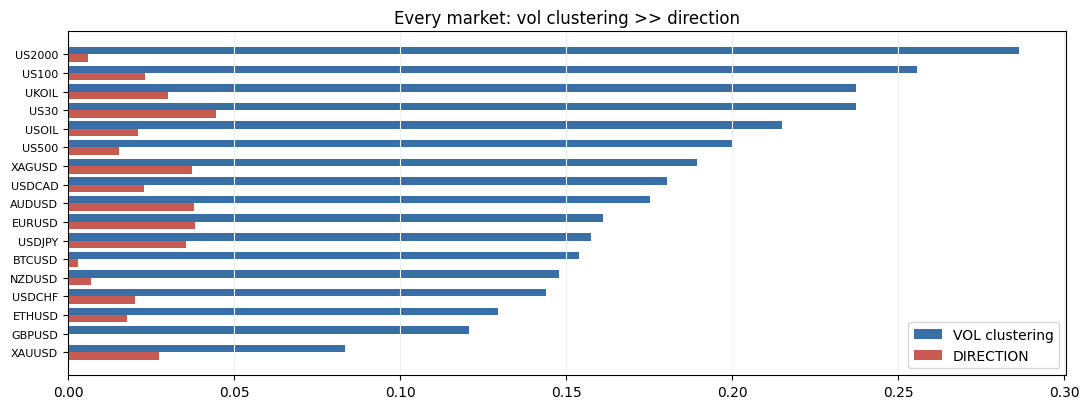

In [13]:
# Proof: vol clustering >> direction on every market.
fig,ax=plt.subplots(figsize=(11,4.2))
syms=list(symbol_series); vol_clust=np.array([autocorr1(np.abs(clean_returns[s])) for s in syms]); dir_mag=np.array([abs(autocorr1(clean_returns[s])) for s in syms])
o=np.argsort(vol_clust); syms=[syms[i] for i in o]; vol_clust=vol_clust[o]; dir_mag=dir_mag[o]; y=np.arange(len(syms))
ax.barh(y+.2,vol_clust,height=.4,color=AC,label="VOL clustering"); ax.barh(y-.2,dir_mag,height=.4,color=RD,label="DIRECTION")
ax.set_yticks(y); ax.set_yticklabels(syms,fontsize=8); ax.set_title("Every market: vol clustering >> direction"); ax.legend(loc="lower right"); ax.grid(True,color=GR,axis="x")
plt.tight_layout(); plt.show()

One more guard before we start naming weather. Sorting *anything* into low / medium / high produces a tidy-looking spread, even pure noise with nothing in it - so a tidy spread is never evidence of a signal. We show it three ways on pure Gaussian noise: a fixed $\pm 0.5$ band, a sort by rank into thirds, and the notebook's own standardisation (turn the noise into 20-day roughness, then past-only z-score it) with the $\pm 0.5$ band. Each makes a spread from nothing.

In [14]:
# A tidy 3-way spread is a property of the SORTING, not evidence of signal.
# Demonstrate on pure Gaussian noise, three ways. Self-contained (own rng, inline helpers).
rng = np.random.default_rng(4)

def _split(labels):
    return "/".join(f"{100*np.mean(labels == k):.0f}" for k in (0, 1, 2))

# (a) fixed +-0.5 band on standard-normal noise
noise = rng.standard_normal(400_000)
band = np.where(noise > 0.5, 2, np.where(noise < -0.5, 0, 1))

# (b) sort by rank into thirds (forces an even split, an artefact of the method)
ranks = np.argsort(np.argsort(noise)) / len(noise)
by_rank = np.where(ranks > 2/3, 2, np.where(ranks < 1/3, 0, 1))

# (c) the notebook's own standardisation on noise: 20-day roughness -> past-only z -> +-0.5
std_labels = []
for _ in range(17):
    ret = rng.standard_normal(6000)
    vol = np.array([np.mean(np.abs(ret[i*20:(i+1)*20])) for i in range(len(ret)//20)])
    z = np.full(len(vol), np.nan)
    for i in range(24, len(vol)):
        base = vol[i-24:i]; z[i] = (vol[i] - base.mean()) / (base.std() + 1e-12)
    valid = z[~np.isnan(z)]
    std_labels.append(np.where(valid > 0.5, 2, np.where(valid < -0.5, 0, 1)))
std_labels = np.concatenate(std_labels)

print(f"pure-noise 3-band split  fixed +-0.5   : {_split(band)}")
print(f"pure-noise 3-band split  by rank       : {_split(by_rank)}")
print(f"pure-noise 3-band split  standardisation: {_split(std_labels)}")

pure-noise 3-band split  fixed +-0.5   : 31/38/31
pure-noise 3-band split  by rank       : 33/33/33
pure-noise 3-band split  standardisation: 33/37/30


## Step 2 - Turning volatility into a label

To forecast weather we first have to *name* it. We chop each series into blocks, measure each block's volatility, standardize it against its recent past, and cut the result into calm / normal / stormy. The very first decision - how to window the blocks - hides a trap.

### The overlap catch (why weekly -> monthly)

A 20-day volatility window stepped **weekly** overlaps 75% with its neighbour, so adjacent labels are almost the same measurement twice; that inflates apparent persistence badly (a 75% persistence was roughly 85% artefact). Measured on **non-overlapping** blocks the honest truth is: weekly +3.4% (weak), monthly +14.2%. So we label on non-overlapping ~1-month blocks.

We now define the labelling toolkit **once**, and every experiment below reuses it (earlier drafts had six subtly different copies that disagreed on the zero-variance guard; this is the reconciliation).

**Block volatility** - for non-overlapping blocks of $B$ trading days, the block volatility is the mean absolute return in the block:

$$v_k \;=\; \frac{1}{B} \sum_{t \in \text{block } k} |r_t|, \qquad k = 0, 1, \dots, \lfloor T/B \rfloor - 1.$$

**Rolling z-score** - each block is standardized against the previous $W$ blocks only (past-only), with a small $\varepsilon$ guarding a zero-variance window:

$$z_k \;=\; \frac{v_k - \mu_k}{\sigma_k + \varepsilon}, \qquad \mu_k = \tfrac{1}{W}\!\!\sum_{j=k-W}^{k-1}\!\! v_j, \quad \sigma_k = \operatorname{std}(v_{k-W:k}), \quad \varepsilon = 10^{-12}.$$

**Band** - calm / normal / stormy according to $z < -0.5$ / $|z| \le 0.5$ / $z > 0.5$.

**Persistence rate** - the fraction of adjacent blocks that keep the same label, compared against the base rate (frequency of the most common label):

$$\text{persistence} \;=\; \frac{1}{N-1} \sum_{k=1}^{N-1} \mathbf{1}[\ell_k = \ell_{k-1}], \qquad \text{base} = \max_c \frac{\#\{\ell = c\}}{N}.$$

In [15]:
EPS = 1e-12   # canonical zero-variance guard, adopted for every rolling z-score below

def blocks(returns, block_len):
    """Mean |return| in each non-overlapping block of `block_len` trading days."""
    n_blocks = len(returns) // block_len
    return np.array([np.mean(np.abs(returns[i*block_len:(i+1)*block_len])) for i in range(n_blocks)])

def rolling_zscore(vol_series, baseline_window=24):
    """Past-only z-score of each block vs the previous `baseline_window` blocks (NaN before it exists)."""
    zscore = np.full(len(vol_series), np.nan)
    for i in range(baseline_window, len(vol_series)):
        baseline = vol_series[i-baseline_window:i]
        zscore[i] = (vol_series[i] - baseline.mean()) / (baseline.std() + EPS)
    return zscore

def band_labels(vol_series, baseline_window=24, thr=0.5):
    """calm=0 / normal=1 / stormy=2 from the rolling z-score; -1 where the z-score is undefined."""
    zscore = rolling_zscore(vol_series, baseline_window)
    labels = np.full(len(vol_series), -1)
    valid = ~np.isnan(zscore)
    labels[valid] = np.where(zscore[valid] > thr, 2, np.where(zscore[valid] < -thr, 0, 1))
    return labels

def persistence_and_base(vol_series, baseline_window=24):
    """Persistence rate and base rate over the labelled blocks, or None if too few."""
    labels = band_labels(vol_series, baseline_window)
    labels = labels[labels >= 0]
    if len(labels) < 3:
        return None
    persistence = np.mean(labels[:-1] == labels[1:])
    base = Counter(labels).most_common(1)[0][1] / len(labels)
    return persistence, base

def vol_overlap(returns, window=20):
    """Deliberately-overlapping baseline: 20-day trailing vol stepped WEEKLY (5 days)."""
    out = []; i = window
    while i <= len(returns):
        out.append(np.mean(np.abs(returns[i-window:i]))); i += 5
    return np.array(out)

Now the overlap catch in numbers: run the *same* persistence measure three ways - the overlapping weekly window, non-overlapping 5-day (~week) blocks, and non-overlapping 20-day (~month) blocks - and watch the inflated signal deflate to its honest size.

In [16]:
windowings = [
    ("OVERLAP weekly/20d",        lambda returns: vol_overlap(returns)),
    ("NON-overlap 5d (~week)",    lambda returns: blocks(returns, 5)),
    ("NON-overlap 20d (~month)",  lambda returns: blocks(returns, 20)),
]
rows = []
for name, windowing in windowings:
    persistences = []; bases = []
    for symbol in symbol_series:
        result = persistence_and_base(windowing(clean_returns[symbol]))
        if result:
            persistences.append(result[0]); bases.append(result[1])
    p, b = 100*np.mean(persistences), 100*np.mean(bases)
    rows.append((name, p, b, p - b))

print("=" * 56)
print(f"{'windowing':26s}{'persist':>9s}{'base':>8s}{'signal':>9s}")
print("-" * 56)
for name, p, b, sig in rows:
    print(f"{name:26s}{p:8.1f}%{b:7.1f}%{sig:8.1f}%")
print("=" * 56)

windowing                   persist    base   signal
--------------------------------------------------------
OVERLAP weekly/20d            71.5%   40.9%    30.6%
NON-overlap 5d (~week)        40.8%   37.4%     3.4%
NON-overlap 20d (~month)      54.8%   40.6%    14.2%


The overlapping window reports a proud persistence with a large apparent signal; step to non-overlapping blocks and most of it evaporates. The weekly signal is barely there, and the monthly signal settles at the honest figure we will hold ourselves to. Overlap was inflating the truth several-fold.

The same overlap trap, seen as a regression. Standardise each market's *overlapping* weekly roughness (the 20-day window stepped 5 days, so neighbours share 15 of 20 days) and regress next window's vol-z on this window's. Because the two windows are mostly the same measurement, the $R^2$ comes out enormous - the inflated artefact this chapter exists to debunk. Set it beside the honest monthly $R^2 \approx 0.27$ from the feature lab below.

In [17]:
# Weekly-overlap R^2: regress next overlapping-window vol-z on current vol-z (pooled).
def _r2(x, y):
    A = np.column_stack([x, np.ones(len(x))])
    coef = np.linalg.lstsq(A, y, rcond=None)[0]
    return 1 - np.sum((y - A @ coef)**2) / np.sum((y - y.mean())**2)

cur_z = []; next_z = []; cur_raw = []; next_raw = []
for symbol in symbol_series:
    vol = vol_overlap(clean_returns[symbol])          # 20d window stepped weekly (overlap)
    z = rolling_zscore(vol, 24)
    for t in range(24, len(z) - 1):
        if not (np.isnan(z[t]) or np.isnan(z[t+1])):
            cur_z.append(z[t]); next_z.append(z[t+1])
    cur_raw.extend(vol[:-1]); next_raw.extend(vol[1:])
r2_z = _r2(np.array(cur_z), np.array(next_z))
r2_raw = _r2(np.array(cur_raw), np.array(next_raw))
print(f"WEEKLY OVERLAP (inflated artefact): R2 on vol-z = {r2_z:.2f}   "
      f"(on raw vol = {r2_raw:.2f})")
print("  vs honest monthly non-overlap feature-lab R2 ~ 0.27 -> overlap was inflating it.")

WEEKLY OVERLAP (inflated artefact): R2 on vol-z = 0.70   (on raw vol = 0.95)
  vs honest monthly non-overlap feature-lab R2 ~ 0.27 -> overlap was inflating it.


### Label definition and the baseline-window lab (12 / 24 / 36 -> 24)

With the block = 20 trading days fixed, one knob remains for the label itself: how many past blocks the rolling z-score looks back over. Too short and the labels chatter; too long and they freeze. We sweep 12, 24, 36 blocks and read persistence, run-length, and forecast signal.

The run-length helper: average number of consecutive blocks before the label changes (a plain-language read on how 'sticky' the regime is).

In [18]:
def runlen(labels):
    labels = labels[labels >= 0]
    if len(labels) == 0:
        return 0
    return len(labels) / (1 + sum(labels[i] != labels[i-1] for i in range(1, len(labels))))

vol_blocks = {symbol: blocks(clean_returns[symbol], 20) for symbol in symbol_series}

A quick shape check on the block dictionary before we sweep it.

In [19]:
assert all(vol_blocks[symbol].ndim == 1 for symbol in symbol_series)
len(vol_blocks), vol_blocks["EURUSD"].shape

(17, (293,))

Now the sweep over the baseline window, laid out as a boxed table.

In [20]:
rows = []
for baseline_window in (12, 24, 36):
    all_labels = []; persistences = []; bases = []
    for symbol in symbol_series:
        labels = band_labels(vol_blocks[symbol], baseline_window)
        labeled = labels[labels >= 0]; all_labels.append(labeled)
        if len(labeled) > 3:
            persistences.append(np.mean(labeled[:-1] == labeled[1:]))
            bases.append(Counter(labeled).most_common(1)[0][1] / len(labeled))
    labels_all = np.concatenate(all_labels)
    freq = "/".join(f"{100*np.mean(labels_all == k):.0f}" for k in (0, 1, 2))
    mean_runlen = np.mean([runlen(band_labels(vol_blocks[symbol], baseline_window)) for symbol in symbol_series])
    signal = 100 * (np.mean(persistences) - np.mean(bases))
    rows.append((baseline_window, len(labels_all), freq, mean_runlen, signal))

print("=" * 56)
print(f"{'baseline':>9s}{'n':>7s}{'calm/norm/storm':>18s}{'runlen':>8s}{'signal':>9s}")
print("-" * 56)
for baseline_window, n, freq, mean_runlen, signal in rows:
    print(f"{baseline_window:6d}blk{n:7d}{freq:>18s}{mean_runlen:8.1f}{signal:8.1f}%")
print("=" * 56)

 baseline      n   calm/norm/storm  runlen   signal
--------------------------------------------------------
    12blk   5542          41/30/29     2.0     9.3%
    24blk   5338          41/32/27     2.2    14.2%
    36blk   5134          40/33/26     2.4    16.5%


The shortest window is noisy, the longest is static and buys only a little more signal at the cost of samples; 24 blocks is the balance point. We keep the **24-block baseline** from here on.

Why the baseline window was load-bearing, made concrete. Label every month three times - with a 12-, 24- and 36-block rolling baseline - and count how often the three labelings agree, over the blocks where all three are defined. If the choice were harmless the labels would nearly always match; instead they agree only about three times in four, which is what marks this knob as one to pin by principle rather than wave through.

In [21]:
# Pairwise agreement of the calm/normal/stormy labels under 12 / 24 / 36-block baselines.
lab_12 = []; lab_24 = []; lab_36 = []
for symbol in symbol_series:
    l12 = band_labels(vol_blocks[symbol], 12)
    l24 = band_labels(vol_blocks[symbol], 24)
    l36 = band_labels(vol_blocks[symbol], 36)
    both = (l12 >= 0) & (l24 >= 0) & (l36 >= 0)     # compare only where all three exist
    lab_12.append(l12[both]); lab_24.append(l24[both]); lab_36.append(l36[both])
lab_12 = np.concatenate(lab_12); lab_24 = np.concatenate(lab_24); lab_36 = np.concatenate(lab_36)
agree = np.mean([np.mean(lab_12 == lab_24), np.mean(lab_12 == lab_36), np.mean(lab_24 == lab_36)])
print(f"baseline 12 vs 24 vs 36: labels agree {100*agree:.0f}% of the time "
      f"(12-24 {100*np.mean(lab_12==lab_24):.0f}%, 12-36 {100*np.mean(lab_12==lab_36):.0f}%, "
      f"24-36 {100*np.mean(lab_24==lab_36):.0f}%) -> LOAD-BEARING")

baseline 12 vs 24 vs 36: labels agree 76% of the time (12-24 76%, 12-36 68%, 24-36 85%) -> LOAD-BEARING


### Re-confirming the label: normalization method and number of levels

Two more knobs could each be a hidden choice we are making by taste. Test them.

**Normalization method** - the z-score assumes the baseline is roughly symmetric. Compare it against a log-z (for skew), a robust median/MAD version, and a rank/percentile version. If all four agree on the labels, the choice is not load-bearing. The z-branch reuses `band_labels` exactly; the others share the same $\varepsilon$ guard.

In [22]:
# method: z / logz / mad / percentile (rolling 24 blocks, 3 levels +-0.5)
def lab_method(vol_series, method, baseline_window=24, thr=0.5):
    if method == "z":
        return band_labels(vol_series, baseline_window, thr)      # canonical rolling z-score
    labels = np.full(len(vol_series), -1)
    for i in range(baseline_window, len(vol_series)):
        baseline = vol_series[i-baseline_window:i]; x = vol_series[i]
        if method == "pct":
            p = np.mean(baseline < x); labels[i] = 2 if p > 0.67 else (0 if p < 0.33 else 1); continue
        if method == "mad":
            med = np.median(baseline); scale = np.median(np.abs(baseline - med)) * 1.4826
            z = (x - med) / (scale + EPS)
        elif method == "logz":
            log_baseline = np.log(baseline); z = (np.log(x) - log_baseline.mean()) / (log_baseline.std() + EPS)
        labels[i] = 2 if z > thr else (0 if z < -thr else 1)
    return labels

labels_by_method = {m: {symbol: lab_method(vol_blocks[symbol], m) for symbol in symbol_series}
                    for m in ["z", "logz", "mad", "pct"]}

print("=" * 56)
print("METHOD (monthly)")
print(f"{'method':>8s}{'calm/norm/storm':>18s}{'agree-vs-z':>14s}")
print("-" * 56)
for m in ["z", "logz", "mad", "pct"]:
    labels_all = np.concatenate([labels_by_method[m][s][labels_by_method[m][s] >= 0] for s in symbol_series])
    freq = "/".join(f"{100*np.mean(labels_all == k):.0f}" for k in (0, 1, 2))
    if m == "z":
        agree = "-"
    else:
        per_symbol = []
        for s in symbol_series:
            z_lab = labels_by_method["z"][s]; m_lab = labels_by_method[m][s]
            both = (z_lab >= 0) & (m_lab >= 0)
            per_symbol.append(np.mean(z_lab[both] == m_lab[both]))
        agree = f"{100*np.mean(per_symbol):.0f}%"
    print(f"{m:>8s}{freq:>18s}{agree:>14s}")
print("=" * 56)

METHOD (monthly)
  method   calm/norm/storm    agree-vs-z
--------------------------------------------------------
       z          41/32/27             -
    logz          38/31/31           93%
     mad          36/31/34           87%
     pct          37/31/32           90%


The four methods land on almost the same frequencies and agree with the plain z-score most of the time, exactly as they did on the weekly data. The normalization choice is not load-bearing, so we keep the simplest one: **z**.

The other trim knob, checked the same way. Re-winsorise every symbol at the tighter $0.1\% / 99.9\%$ instead of $0.5\% / 99.5\%$, re-label the monthly blocks, and count how often the two labelings disagree. Like the normalisation method, the trim level barely moves the answer - a knob that does not change the label is not worth an argument.

In [23]:
# Trim level: 0.5/99.5 (our clean_returns) vs a tighter 0.1/99.9, compared on the labels.
trim_agreements = []
for symbol in symbol_series:
    raw = raw_returns[symbol]
    lo, hi = np.percentile(raw, (0.1, 99.9))
    clean_tight = np.clip(raw, lo, hi)
    labels_default = band_labels(blocks(clean_returns[symbol], 20), 24)
    labels_tight = band_labels(blocks(clean_tight, 20), 24)
    both = (labels_default >= 0) & (labels_tight >= 0)
    trim_agreements.append(np.mean(labels_default[both] == labels_tight[both]))
print(f"trim 0.5/99.5 vs 0.1/99.9: labels agree {100*np.mean(trim_agreements):.0f}% "
      f"-> knob does not matter, keep the simpler 0.5/99.5")

trim 0.5/99.5 vs 0.1/99.9: labels agree 98% -> knob does not matter, keep the simpler 0.5/99.5

**Number of levels** - is three the right number of weather states, and is $\pm 0.5$ the right cut? Sweep 2 / 3 / 5 levels, and for three levels sweep the threshold $\pm 0.5 / 0.7 / 1.0$. We read the label frequencies, the mean block volatility inside each band (to check the bands are actually separating quiet from violent), and the run-length. `lab_cuts` reuses the same `rolling_zscore`, so the only thing changing is where we cut it.

In [24]:
# levels: 2 / 3 / 5, and 3-level threshold +-0.5/0.7/1.0 (monthly)
def lab_cuts(vol_series, cuts, baseline_window=24):
    zscore = rolling_zscore(vol_series, baseline_window)
    labels = np.full(len(vol_series), -1)
    valid = ~np.isnan(zscore)
    labels[valid] = np.searchsorted(cuts, zscore[valid]).astype(int)
    return labels

def summ(configs, title):
    print("=" * 56)
    print(title)
    print("-" * 56)
    for name, cuts in configs.items():
        all_labels = []; all_vol = []
        for symbol in symbol_series:
            labels = lab_cuts(vol_blocks[symbol], np.array(cuts))
            valid = np.arange(len(vol_blocks[symbol])) >= 24
            all_labels.append(labels[valid]); all_vol.append(vol_blocks[symbol][valid])
        labels = np.concatenate(all_labels); vol = np.concatenate(all_vol) * 100
        n_levels = len(cuts) + 1
        freq = "/".join(f"{100*np.mean(labels == k):.0f}" for k in range(n_levels))
        band_vol = "/".join(f"{vol[labels == k].mean():.2f}" for k in range(n_levels))
        mean_runlen = np.mean([runlen(lab_cuts(vol_blocks[symbol], np.array(cuts))[np.arange(len(vol_blocks[symbol])) >= 24])
                               for symbol in symbol_series])
        print(f"  {name:20s} freq={freq:16s}% vol/band={band_vol:22s} runlen={mean_runlen:.1f}")
    print("=" * 56)

summ({"2": [0.0], "3": [-0.5, 0.5], "5": [-1.0, -0.4, 0.4, 1.0]}, "LEVELS (monthly)")
summ({"3 @+-0.5": [-0.5, 0.5], "3 @+-0.7": [-0.7, 0.7], "3 @+-1.0": [-1.0, 1.0]}, "3-LEVEL THRESHOLD (monthly)")

LEVELS (monthly)
--------------------------------------------------------
  2                    freq=59/41           % vol/band=0.69/1.20              runlen=3.6


  3                    freq=41/32/27        % vol/band=0.63/0.88/1.32         runlen=2.2
  5                    freq=19/25/26/12/18  % vol/band=0.54/0.71/0.88/1.14/1.41 runlen=1.6
3-LEVEL THRESHOLD (monthly)
--------------------------------------------------------


  3 @+-0.5             freq=41/32/27        % vol/band=0.63/0.88/1.32         runlen=2.2
  3 @+-0.7             freq=32/45/23        % vol/band=0.59/0.88/1.36         runlen=2.2


  3 @+-1.0             freq=19/63/18        % vol/band=0.54/0.86/1.41         runlen=2.7


Five levels flicker (short run-lengths), two are too coarse to be useful, and among the thresholds the widest one lets 'normal' swallow everything. Three levels at $\pm 0.5$ keep the bands well separated by their inside-band volatility and reasonably sticky. We lock **3 levels at $\pm 0.5$**.

## Step 3 - The forecast dataset

Now assemble the supervised problem: from each symbol's z-scored monthly volatility, build features (current z and a few lags) and the target (next month's z), then ask a blunt question - which features actually carry information?

**Feature lab.** Fit ordinary least squares of next-month volatility on nested feature sets - current z, then +lag1, +lag2, +lag3 - and read the coefficient of determination

$$R^2 \;=\; 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}.$$

If the extra lags barely raise $R^2$, they are redundant and we drop them. `rolling_zscore` here is the very same helper defined in Step 2.

In [25]:
feature_rows = []; target = []
for symbol in symbol_series:
    zscore = rolling_zscore(vol_blocks[symbol])
    for t in range(27, len(zscore) - 1):
        vals = [zscore[t], zscore[t-1], zscore[t-2], zscore[t-3], zscore[t] - zscore[t-3], zscore[t+1]]
        if any(np.isnan(vals)):
            continue
        feature_rows.append(vals[:5]); target.append(vals[5])
X = np.array(feature_rows); y = np.array(target)

def r2(cols):
    A = np.column_stack([X[:, c] for c in cols] + [np.ones(len(X))])
    coef = np.linalg.lstsq(A, y, rcond=None)[0]
    return 1 - np.sum((y - A @ coef)**2) / np.sum((y - y.mean())**2)

print(f"FEATURE lab (monthly, n={len(y)}):  current R2={r2([0]):.3f}  +lag1={r2([0,1]):.3f}  "
      f"+lag2={r2([0,1,2]):.3f}  +lag3={r2([0,1,2,3]):.3f}")

FEATURE lab (monthly, n=5270):  current R2=0.271  +lag1=0.282  +lag2=0.282  +lag3=0.283


A shape check on the design matrix, and the reading: the current z-score carries almost all of the explainable variance, lag-1 adds only a hair, and further lags add essentially nothing. So the feature set is **[current, lag1]**. (The eye-catching weekly $R^2 \approx 0.79$ from an earlier draft was the overlap artefact again, not signal.)

In [26]:
assert X.shape[1] == 5 and len(X) == len(y)
X.shape, y.shape

((5270, 5), (5270,))

### The audit before deep learning

Before any network, two safety checks. A **leak-placebo**: shuffle the target and confirm the measured persistence drops to chance - if a shuffled target still 'predicts', there is a leak. And a **block-size sensitivity**: confirm the honest signal is not an accident of choosing 20 days.

In [27]:
# AUDIT before DL: leak-placebo + block-size sensitivity.
rng = np.random.default_rng(0)
real = []; shuf = []; base = []
for symbol in symbol_series:
    labels = band_labels(vol_blocks[symbol], 24); labels = labels[labels >= 0]
    if len(labels) < 10:
        continue
    real.append(np.mean(labels[:-1] == labels[1:]))
    shuffled = labels.copy(); rng.shuffle(shuffled)
    shuf.append(np.mean(labels[:-1] == shuffled[1:]))
    base.append(Counter(labels).most_common(1)[0][1] / len(labels))
print(f"LEAK-PLACEBO: real={100*np.mean(real):.1f}%  SHUFFLED-target={100*np.mean(shuf):.1f}%  base={100*np.mean(base):.1f}%")

print("BLOCK-SIZE sensitivity:")
for block_len in (10, 20, 40):
    persistences = []; bases = []
    for symbol in symbol_series:
        labels = band_labels(blocks(clean_returns[symbol], block_len), 24); labels = labels[labels >= 0]
        if len(labels) < 10:
            continue
        persistences.append(np.mean(labels[:-1] == labels[1:]))
        bases.append(Counter(labels).most_common(1)[0][1] / len(labels))
    print(f"  block={block_len:2d}d signal={100*(np.mean(persistences)-np.mean(bases)):.1f}%")

LEAK-PLACEBO: real=54.8%  SHUFFLED-target=34.5%  base=40.6%
BLOCK-SIZE sensitivity:


  block=10d signal=8.5%


  block=20d signal=14.2%
  block=40d signal=16.4%


The placebo passes cleanly: with the target shuffled, 'persistence' falls to around the base rate - roughly a coin-flip given three uneven classes - so there is no hidden leak feeding the real number. And the honest signal grows smoothly with block size (weakest at 10 days, our chosen 20 in the middle, a touch more at 40), so 20 days is a defensible natural month, not a lucky pick.

### Split (methodological, NOT tuned - anti-snooping)
- **TRAIN** = 13 symbols, early blocks. **VALIDATION** = same 13, middle. **TEST-time** = same 13, last 20% (future).
- **TEST-symbol** = 4 held-out markets (US2000/NZDUSD/ETHUSD/UKOIL, one per class), never seen = transfer/snoop test.
- Chosen + declared in advance; test opened once.

Before the deep-learning notebook opens this dataset, one honest picture of the whole pipeline, with a single real US500 block worked end to end so the abstract steps have a concrete example attached.

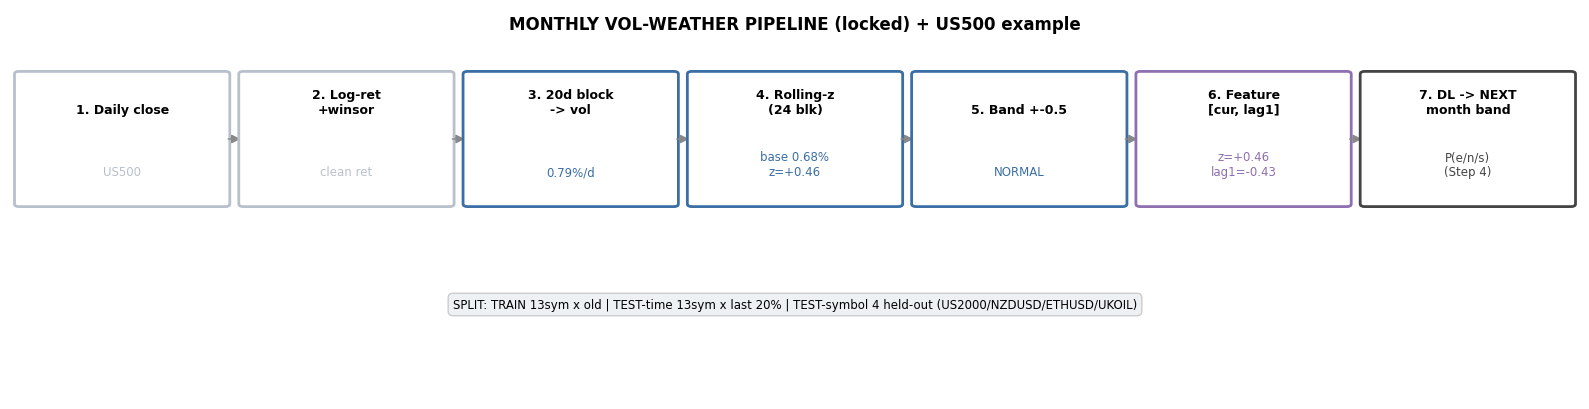

In [28]:
# Pipeline diagram + US500 worked example
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
returns_us=clean_returns["US500"]; vol_series=blocks(returns_us,20); i=len(vol_series)-1
z_series=rolling_zscore(vol_series); z=float(z_series[i]); base=vol_series[i-24:i]
zp=float(z_series[i-1]); band=["calm","normal","stormy"][2 if z>0.5 else (0 if z<-0.5 else 1)]
steps=[("1. Daily close",f"US500",MU),("2. Log-ret\n+winsor","clean ret",MU),("3. 20d block\n-> vol",f"{vol_series[i]*100:.2f}%/d",AC),
       ("4. Rolling-z\n(24 blk)",f"base {base.mean()*100:.2f}%\nz={z:+.2f}",AC),("5. Band +-0.5",f"{band.upper()}",RD if band=='stormy' else (AC if band=='normal' else GRN)),
       ("6. Feature\n[cur, lag1]",f"z={z:+.2f}\nlag1={zp:+.2f}",PUR),("7. DL -> NEXT\nmonth band","P(e/n/s)\n(Step 4)","#444")]
fig,ax=plt.subplots(figsize=(16,4.2)); ax.axis("off"); ax.set_xlim(0,len(steps)); ax.set_ylim(0,3)
for k,(t,v,c) in enumerate(steps):
    x=k+0.5; ax.add_patch(FancyBboxPatch((x-0.46,1.5),0.92,1.0,boxstyle="round,pad=0.02",fc="white",ec=c,lw=2))
    ax.text(x,2.2,t,ha="center",fontsize=9,weight="bold"); ax.text(x,1.72,v,ha="center",fontsize=8.5,color=c)
    if k<len(steps)-1: ax.add_patch(FancyArrowPatch((x+0.46,2.0),(x+0.54,2.0),arrowstyle="-|>",mutation_scale=13,color="#888"))
ax.text(len(steps)/2,2.85,"MONTHLY VOL-WEATHER PIPELINE (locked) + US500 example",ha="center",fontsize=12,weight="bold")
ax.text(len(steps)/2,0.7,"SPLIT: TRAIN 13sym x old | TEST-time 13sym x last 20% | TEST-symbol 4 held-out (US2000/NZDUSD/ETHUSD/UKOIL)",ha="center",fontsize=8.5,bbox=dict(boxstyle="round,pad=0.4",fc=GR,ec="#ccc"))
plt.tight_layout(); plt.show()

## Summary + Limitations + Alarms
| Step | Locked | Why |
|---|---|---|
| 0 Data | 17 sym Yahoo daily; winsor 0.5/99.5; crypto->biz-days | clean glitches, calendar |
| 1 Axis | VOL only (direction dropped) | direction = noise+microstructure |
| 2 Label | 20-day non-overlap blocks; rolling-24 z; 3 levels +-0.5 | no leak + adaptive + balanced |
| 3 Data | features [current,lag1]; target next-month band; split time+symbol | current carries signal; monthly clean |

**Limitations:** worst at transitions (storm onset); weak signal +14% (wrong ~40-45%); regime shift >2yr lags; labels RELATIVE not absolute; blind to true tails (winsor+survivorship); own-symbol misses systemic events; monthly = slow.

**ALARMS (pre-committed) - a result here means STOP & hunt a leak, not celebrate:**
- **DL test >> ~58-60%** (proven ceiling: persistence ~55%, signal +14%) = LEAK/BUG. Expected = DL ~= persistence.
- over-confident calibration; train >> test (overfit); held-out-symbol easier than held-out-time; one symbol/class anomalously high; adding features jumps accuracy (contradicts feature lab).

**What we can trust, and what we cannot.** Notice the shape of this whole section: not one clever result but a chain of audits, each one dismantling a number that looked like signal until we asked the right question of it - the single crisis day, the overlapping window, the wrong null, the unshuffled target. The honest signal that survives all of them is small, and that smallness is the finding. The deep-learning notebook that opens this dataset must beat persistence only slightly; if it clears the ceiling, the alarm above says *hunt the leak*, not celebrate.